## Why are we not getting regrowth with the new simulations?

All scenarios use the nat_v12 parameter file.
All use SSP1 forcing

1. new restart file
2. old restart file
3. bare ground (init density effectively off)

In [2]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

In [3]:
# NATURAL REGENERATION

# 1. new restart
fates_new = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v7/PA_ssp1_nat_regrowth_newrestart.Ea8fbc2fc28-Ff46de7a5.2025-06-26/run/PA_ssp1_nat_regrowth_newrestart.Ea8fbc2fc28-Ff46de7a5.2025-06-26.sofar.nc'
fates_new = xr.open_dataset(fates_new, decode_times=False)


# 2. old restart
fates_old = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v7/PA_ssp1_nat_regrowth_oldrestart.Ea8fbc2fc28-Ff46de7a5.2025-06-26/run/PA_ssp1_nat_regrowth_oldrestart.Ea8fbc2fc28-Ff46de7a5.2025-06-26.sofar.nc'
fates_old = xr.open_dataset(fates_old, decode_times=False)

# 3. bare ground
fates_bg = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v7/PA_ssp1_nat_regrowth_bareground.Ea8fbc2fc28-Ff46de7a5.2025-06-26/run/PA_ssp1_nat_regrowth_bareground.Ea8fbc2fc28-Ff46de7a5.2025-06-26.sofar.nc'
fates_bg  = xr.open_dataset(fates_bg, decode_times=False)

In [5]:
nyears = int(len(fates_new.variables['time'])/12)
time_new = fates_new.variables['time'] / 365.
time_old = fates_old.variables['time'] / 365.
time_bg = fates_bg.variables['time'] / 365.

cohort_size_bins = fates_new.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates_new.variables['fates_levage'][:]

### AGB 

In [6]:
AGB_new = fates_new.FATES_VEGC_ABOVEGROUND_SZPF.sum(dim='fates_levscpf')  * 10000 * 0.001 * 2
AGB_old = fates_old.FATES_VEGC_ABOVEGROUND_SZPF.sum(dim='fates_levscpf')  * 10000 * 0.001 * 2
AGB_bg = fates_bg.FATES_VEGC_ABOVEGROUND_SZPF.sum(dim='fates_levscpf')  * 10000 * 0.001 * 2


### Nplants

In [7]:
nplant_new = fates_new.FATES_NPLANT_SZPF.sum(dim='fates_levscpf')
nplant_old = fates_old.FATES_NPLANT_SZPF.sum(dim='fates_levscpf')
nplant_bg = fates_bg.FATES_NPLANT_SZPF.sum(dim='fates_levscpf')


Text(0.5, 0, 'Time (years)')

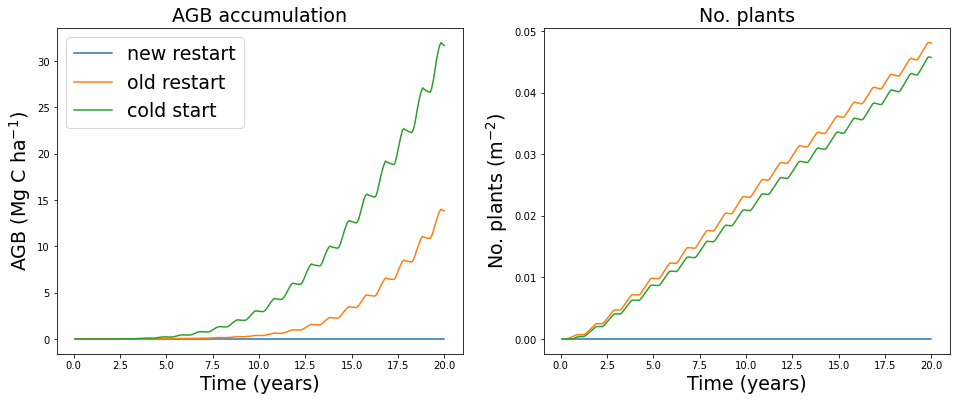

In [8]:

fig1, ((f1ax0,f1ax1)) = plt.subplots(nrows=1,ncols=2, figsize=(16,6))

f1ax0.plot(time_new, AGB_new,  label = 'new restart')  
f1ax0.plot(time_old, AGB_old,  label = 'old restart')
f1ax0.plot(time_bg, AGB_bg, label = 'cold start')
f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)   
f1ax0.legend(fontsize=19)

f1ax1.plot(time_new, nplant_new,  label = 'new restart')  
f1ax1.plot(time_old, nplant_old,  label = 'old restart')
f1ax1.plot(time_bg, nplant_bg, label = 'cold start')
f1ax1.set_title(r'No. plants', fontsize = 19)
f1ax1.set_ylabel(r'No. plants (m$^{-2}$)', fontsize = 19)
f1ax1.set_xlabel(r'Time (years)', fontsize = 19)   




### Seed variables 

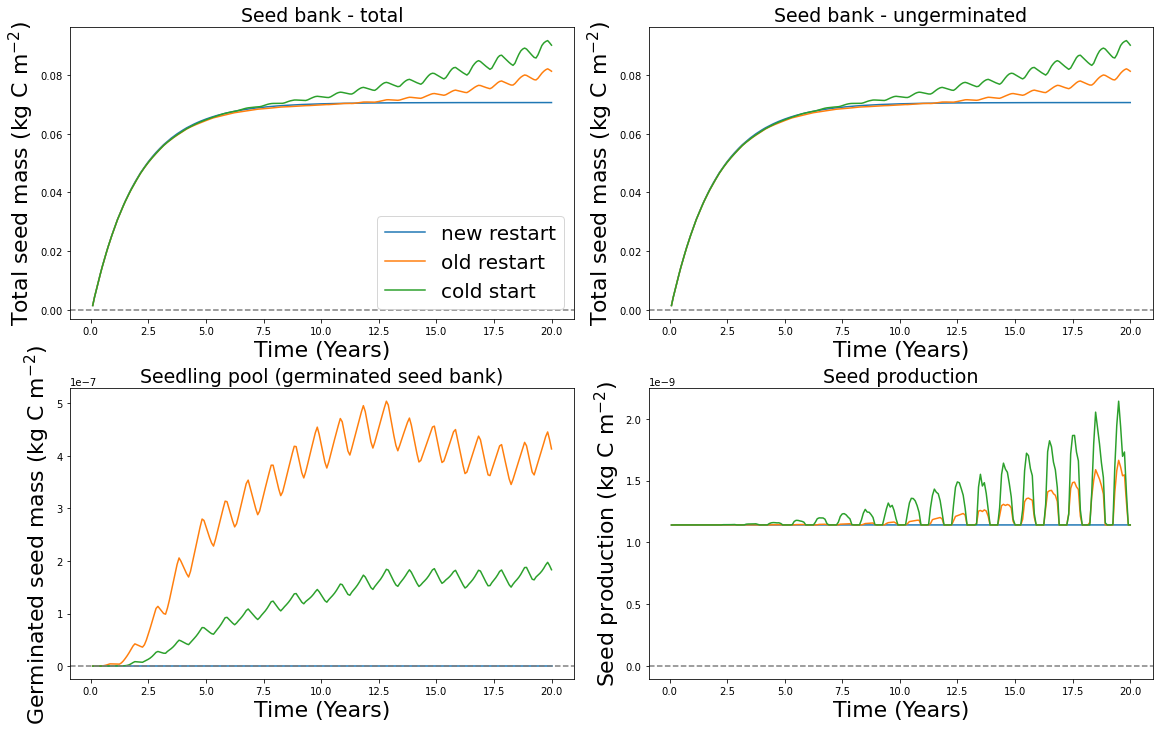

In [10]:
fig1, ((f1ax0, f1ax1), (f1ax2,f1ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(16,10), constrained_layout=True)

f1ax0.plot(time_new, fates_new.FATES_SEED_BANK,label='new restart')   
f1ax0.plot(time_old, fates_old.FATES_SEED_BANK,label='old restart')   
f1ax0.plot(time_bg, fates_bg.FATES_SEED_BANK,label='cold start')   
f1ax0.set_title(r'Seed bank - total', fontsize = 19)
f1ax0.set_xlabel(r'Time (Years)', fontsize=22)
f1ax0.set_ylabel(r'Total seed mass (kg C m$^{-2}$)', fontsize=22)
f1ax0.axhline(0, linestyle='--', color='grey')
f1ax0.legend(fontsize=20)

f1ax1.plot(time_new, fates_new.FATES_UNGERM_SEED_BANK)   
f1ax1.plot(time_old, fates_old.FATES_UNGERM_SEED_BANK)   
f1ax1.plot(time_bg, fates_bg.FATES_UNGERM_SEED_BANK)   
f1ax1.set_title(r'Seed bank - ungerminated', fontsize = 19)
f1ax1.set_xlabel(r'Time (Years)', fontsize=22)
f1ax1.set_ylabel(r'Total seed mass (kg C m$^{-2}$)', fontsize=22)
f1ax1.axhline(0, linestyle='--', color='grey')


f1ax2.plot(time_new, fates_new.FATES_SEEDLING_POOL)  
f1ax2.plot(time_old, fates_old.FATES_SEEDLING_POOL)  
f1ax2.plot(time_bg, fates_bg.FATES_SEEDLING_POOL)  
f1ax2.set_title(r'Seedling pool (germinated seed bank)', fontsize = 19)
f1ax2.set_xlabel(r'Time (Years)', fontsize=22)
f1ax2.set_ylabel(r'Germinated seed mass (kg C m$^{-2}$)', fontsize=22)
f1ax2.axhline(0, linestyle='--', color='grey')

f1ax3.plot(time_new, fates_new.FATES_SEEDS_IN)   
f1ax3.plot(time_old, fates_old.FATES_SEEDS_IN)   
f1ax3.plot(time_bg, fates_bg.FATES_SEEDS_IN)   
f1ax3.set_title(r'Seed production', fontsize = 19)
f1ax3.set_xlabel(r'Time (Years)', fontsize=22)
f1ax3.set_ylabel(r'Seed production (kg C m$^{-2}$)', fontsize=22)
f1ax3.axhline(0, linestyle='--', color='grey')

### Soils?

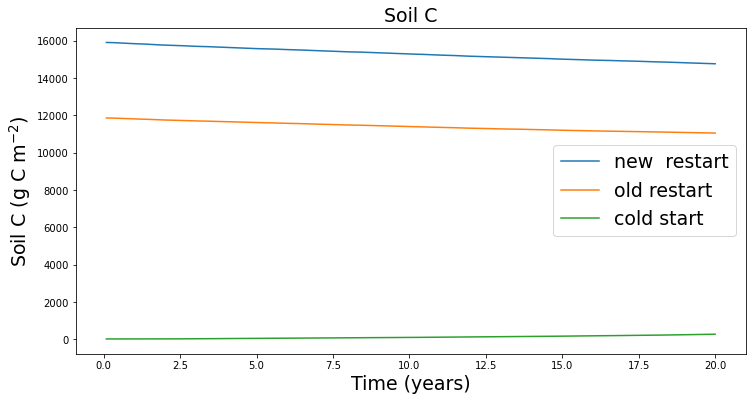

In [12]:
soilC_new = fates_new.SOILC 
soilC_old = fates_old.SOILC 
soilC_bg = fates_bg.SOILC 


fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time_new, soilC_new, label = 'new  restart') 
f1ax0.plot(time_old, soilC_old, label = 'old restart')
f1ax0.plot(time_bg, soilC_bg, label = 'cold start')
f1ax0.set_title(r'Soil C', fontsize = 19)
f1ax0.set_ylabel(r'Soil C (g C m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
f1ax0.legend(fontsize=19)